# 🤖 Influência da IA no Trabalho — Análise de Burnout e Atrito Profissional

Este notebook investiga como a adoção de ferramentas de Inteligência Artificial no ambiente de trabalho impacta indicadores-chave de bem-estar e retenção de profissionais de tecnologia.

**Dataset:** `ai_worker_burnout_attrition_2026.csv`  
**Objetivo:** Identificar padrões entre uso de IA, burnout, produtividade, satisfação e risco de atrito.

---


## 1. 📦 Importação de Bibliotecas e Carregamento dos Dados

Nesta etapa, importamos a biblioteca `pandas` para manipulação de dados e carregamos o dataset principal.


In [33]:
import pandas as pd

In [34]:
df = pd.read_csv("ai_worker_burnout_attrition_2026.csv")

## 2. 🔍 Exploração Inicial do Dataset

Realizamos uma inspeção inicial para entender a estrutura, dimensões e qualidade dos dados:
- **`head()` / `tail()`**: Visualização das primeiras e últimas linhas para conferir o formato das entradas.
- **`info()`**: Tipos de dados, contagem de não-nulos e uso de memória.
- **`describe()`**: Estatísticas descritivas das variáveis numéricas (média, desvio padrão, quartis).
- **Duplicatas**: Verificação de registros repetidos.
- **Colunas**: Listagem numerada de todas as features disponíveis.


In [35]:
df.head(10)

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium
5,EMP0006,Data Analyst,12,Self-taught,Germany,Healthtech,Large (1000-5000),On-site,19,106,...,5,5.7,23,Optimizing,6.7,66,61,3.5,Medium,Low
6,EMP0007,AI Ethics Officer,12,PhD,USA,Gaming,Enterprise (5000+),Fully Remote,46,154,...,1,2.7,45,Optimizing,8.1,54,33,3.5,High,Low
7,EMP0008,Data Scientist,19,Bootcamp,Singapore,Consulting,Enterprise (5000+),Hybrid,44,54,...,7,4.7,46,Optimizing,9.1,43,57,2.9,Low,Medium
8,EMP0009,Data Analyst,6,Master,Germany,Fintech,Mid (200-1000),Hybrid,42,55,...,7,2.8,56,Experimenting,8.1,69,52,2.8,Low,Medium
9,EMP0010,Prompt Engineer,2,Bachelor,Netherlands,Gaming,Large (1000-5000),On-site,15,61,...,5,1.8,8,Optimizing,9.7,64,27,3.8,Medium,Low


In [36]:
df.tail()

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
1495,EMP1496,Frontend Engineer,2,Master,Brazil,Fintech,Enterprise (5000+),Hybrid,36,47,...,7,6.9,69,Integrating,2.6,74,63,3.1,High,Medium
1496,EMP1497,Prompt Engineer,1,PhD,UK,E-commerce,Small (50-200),Hybrid,22,199,...,1,1.2,7,Integrating,6.9,39,25,3.5,Low,Low
1497,EMP1498,Backend Engineer,8,Bachelor,Canada,Cybersecurity,Mid (200-1000),Hybrid,48,120,...,3,6.8,73,Optimizing,4.0,44,65,2.9,High,High
1498,EMP1499,AI Ethics Officer,13,Self-taught,Netherlands,Media,Startup (<50),Fully Remote,41,208,...,6,3.2,68,Optimizing,4.1,77,53,2.8,Low,Medium
1499,EMP1500,Frontend Engineer,15,Self-taught,Australia,SaaS,Large (1000-5000),Hybrid,29,212,...,7,5.1,53,Integrating,2.8,50,51,3.5,Low,Medium


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   employee_id                     1500 non-null   str    
 1   job_role                        1500 non-null   str    
 2   years_experience                1500 non-null   int64  
 3   education_level                 1500 non-null   str    
 4   country                         1500 non-null   str    
 5   industry                        1500 non-null   str    
 6   company_size                    1500 non-null   str    
 7   remote_work_type                1500 non-null   str    
 8   team_size                       1500 non-null   int64  
 9   salary_usd_k                    1500 non-null   int64  
 10  primary_ai_tool                 1500 non-null   str    
 11  ai_tools_used_per_day           1500 non-null   int64  
 12  hours_with_ai_assistance_daily  1500 non-null

In [38]:
df.describe()

,years_experience,team_size,salary_usd_k,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5
count,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,9.947333,24.812667,140.734000,4.05600,4.233733,41.248667,4.985533,57.543333,50.057333,3.334733
std,5.460932,13.682582,59.717429,1.97403,2.148387,21.658214,2.913933,10.726952,11.437771,0.636692
min,1.000000,2.000000,40.000000,1.00000,0.500000,5.000000,0.000000,25.000000,16.000000,1.300000
25%,5.000000,13.000000,91.000000,2.00000,2.400000,22.750000,2.400000,50.000000,42.000000,2.900000
50%,10.000000,25.000000,139.000000,4.00000,4.200000,40.000000,5.000000,57.000000,50.000000,3.300000
75%,15.000000,36.000000,190.000000,6.00000,6.100000,60.000000,7.500000,65.000000,58.000000,3.800000
max,19.000000,49.000000,249.000000,7.00000,8.000000,79.000000,10.000000,95.000000,86.000000,5.000000


In [39]:
df.duplicated().sum()

np.int64(0)

In [40]:
c = 0
for i in df.columns:
  c += 1
  print(f"{c}: {i}")

1: employee_id
2: job_role
3: years_experience
4: education_level
5: country
6: industry
7: company_size
8: remote_work_type
9: team_size
10: salary_usd_k
11: primary_ai_tool
12: ai_tools_used_per_day
13: hours_with_ai_assistance_daily
14: ai_replaces_my_tasks_pct
15: ai_adoption_stage
16: weekly_ai_upskilling_hrs
17: productivity_score
18: burnout_score
19: job_satisfaction_1_5
20: fear_of_ai_replacement
21: attrition_risk


## 3. 📊 Configuração da Visualização

Importamos as bibliotecas `matplotlib` e `seaborn` e definimos o estilo visual padrão (`whitegrid`) para garantir consistência nos gráficos ao longo da análise.


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
sns.set_style(style="whitegrid")

## 4. 🧹 Tratamento de Outliers

Antes de analisar os dados, removemos valores extremos que poderiam distorcer os resultados.

### 4.1 — Outliers Globais (IQR Ajustado)

A função `clean_outliers` aplica o método IQR (*Interquartile Range*) com fator `1.2` (mais restritivo que o padrão `1.5`) nas colunas numéricas mais sensíveis:
- `productivity_score`
- `burnout_score`
- `hours_with_ai_assistance_daily`
- `ai_tools_used_per_day`


In [43]:
def clean_outliers(df_in, columns, factor=1.2):
    df_out = df_in.copy()
    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        df_out = df_out[(df_out[col] >= lower) & (df_out[col] <= upper)]
    return df_out

cols_to_clean = ['productivity_score', 'burnout_score', 'hours_with_ai_assistance_daily', 'ai_tools_used_per_day']

df = clean_outliers(df, cols_to_clean)


### 4.2 — Outliers por Grupo (Experiência × Burnout)

Aplicamos uma remoção de outliers **por grupo**, segmentando pelo campo `years_experience`. Isso garante que o burnout seja comparado de forma justa dentro de cada faixa de senioridade, evitando viés causado por grupos com distribuições muito distintas.


In [44]:
def remove_group_outliers(df, group_col, target_col):
    # Calcula os limites de quantil para cada grupo mantendo o alinhamento das linhas
    Q1 = df.groupby(group_col)[target_col].transform('quantile', 0.25)
    Q3 = df.groupby(group_col)[target_col].transform('quantile', 0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    # Filtra mantendo a integridade de todas as colunas originais
    return df[(df[target_col] >= lower) & (df[target_col] <= upper)]

df = remove_group_outliers(df, 'years_experience', 'burnout_score')


## 5. 🔥 Mapa de Correlação

Visualizamos a matriz de correlação entre todas as variáveis numéricas do dataset. O mapa de calor (`heatmap`) com escala `coolwarm` facilita a identificação de relações positivas (vermelho) e negativas (azul) entre os indicadores analisados.


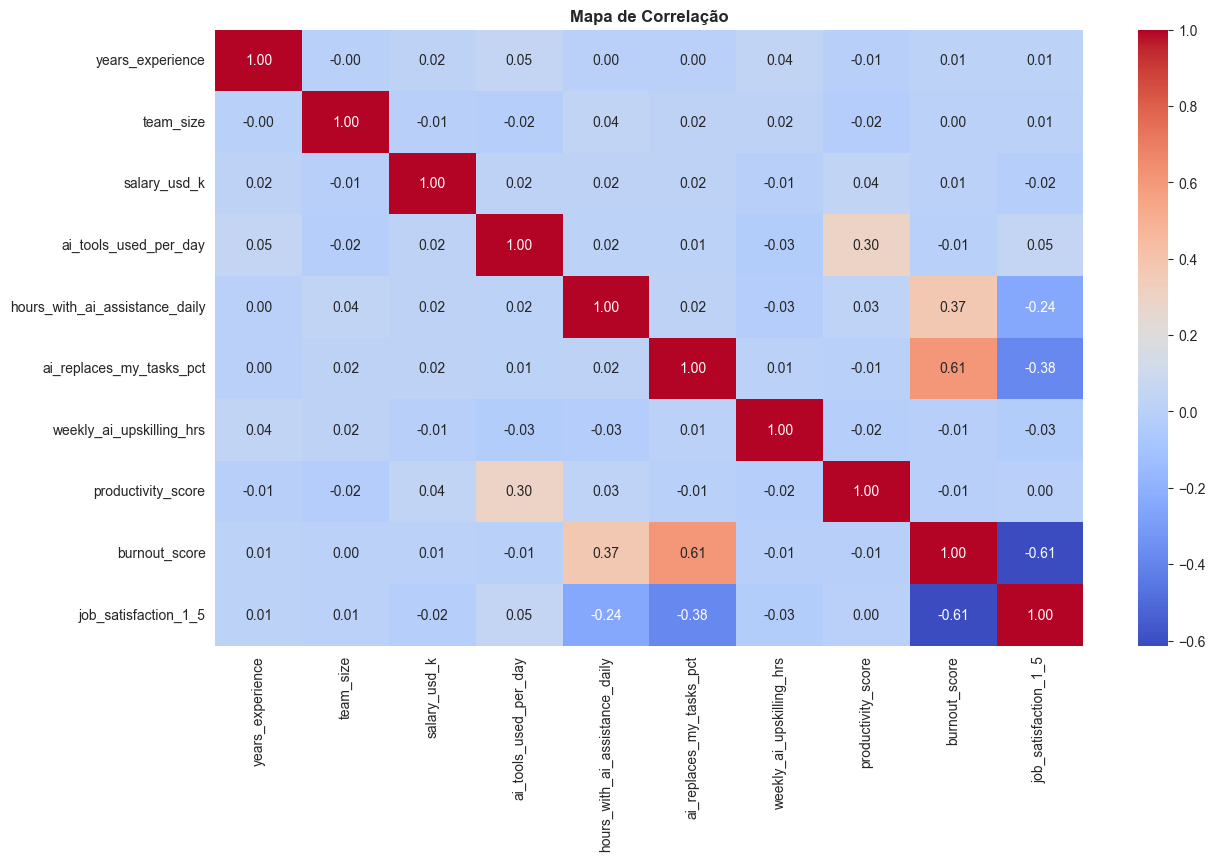

In [45]:
plt.figure(figsize=(14, 8))
numeric_cols = df.select_dtypes(include=['float64','int64'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Mapa de Correlação", fontweight='bold')
plt.show()

## 6. 🛠️ Ferramentas de IA Mais Utilizadas

Identificamos quais ferramentas de IA são mais adotadas pelos profissionais. O gráfico de contagem (`countplot`) exibe a distribuição de usuários por ferramenta principal (`primary_ai_tool`), ordenada da mais para a menos utilizada.


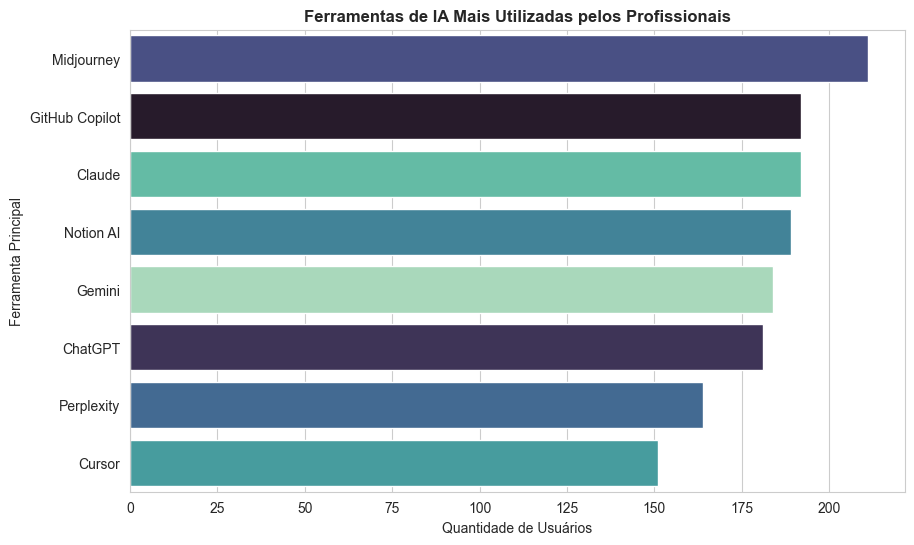

In [46]:
plt.figure(figsize=(10, 6))
ferramentas_order = df['primary_ai_tool'].value_counts().index

sns.countplot(data=df, y='primary_ai_tool', order=ferramentas_order, hue='primary_ai_tool', palette='mako', legend=False)
plt.title('Ferramentas de IA Mais Utilizadas pelos Profissionais', fontweight='bold')
plt.xlabel('Quantidade de Usuários')
plt.ylabel('Ferramenta Principal')
plt.show()

## 7. 🧑‍💻 Taxa de Substituição de Tarefas por Cargo

Analisamos a média percentual de tarefas substituídas pela IA (`ai_replaces_my_tasks_pct`) em cada cargo de TI. Cargos com maior taxa de automação são mais vulneráveis a mudanças no escopo de trabalho, o que pode impactar diretamente a satisfação e o risco de atrito.


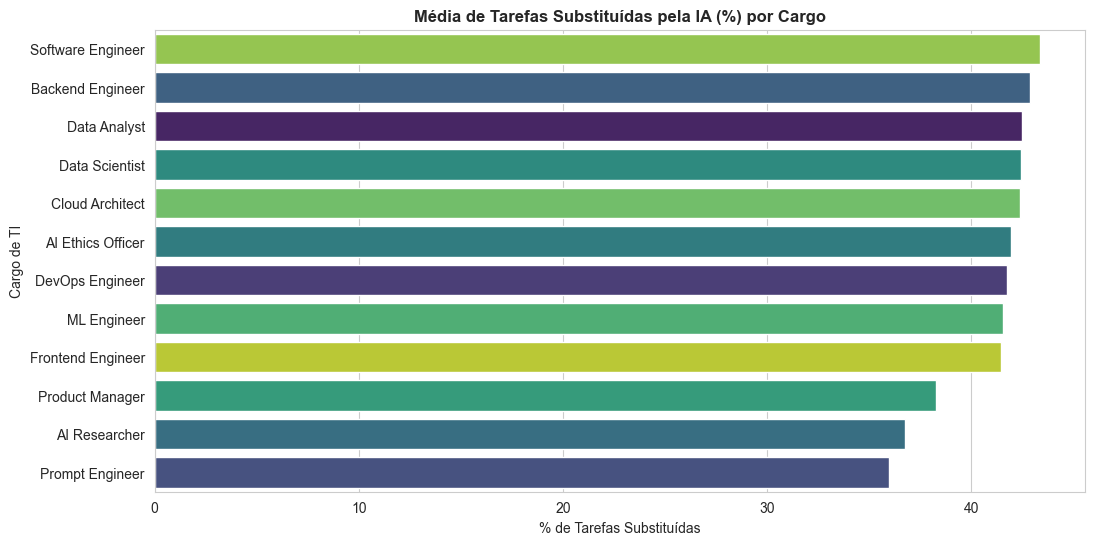

In [47]:
plt.figure(figsize=(12, 6))
order_roles = df.groupby('job_role')['ai_replaces_my_tasks_pct'].mean().sort_values(ascending=False).index

sns.barplot(data=df, x='ai_replaces_my_tasks_pct', y='job_role', order=order_roles, hue='job_role', palette='viridis', errorbar=None, legend=False)
plt.title('Média de Tarefas Substituídas pela IA (%) por Cargo', fontweight='bold')
plt.xlabel('% de Tarefas Substituídas')
plt.ylabel('Cargo de TI')
plt.show()

## 8. 📈 Distribuições de Produtividade e Uso de IA

Analisamos as distribuições das duas variáveis centrais:
- **Produtividade (`productivity_score`)**: Compreender o perfil geral dos trabalhadores avaliados.
- **Horas diárias com IA (`hours_with_ai_assistance_daily`)**: Entender o volume de uso de ferramentas de IA no cotidiano.

As curvas KDE (*Kernel Density Estimation*) auxiliam na visualização da forma das distribuições.


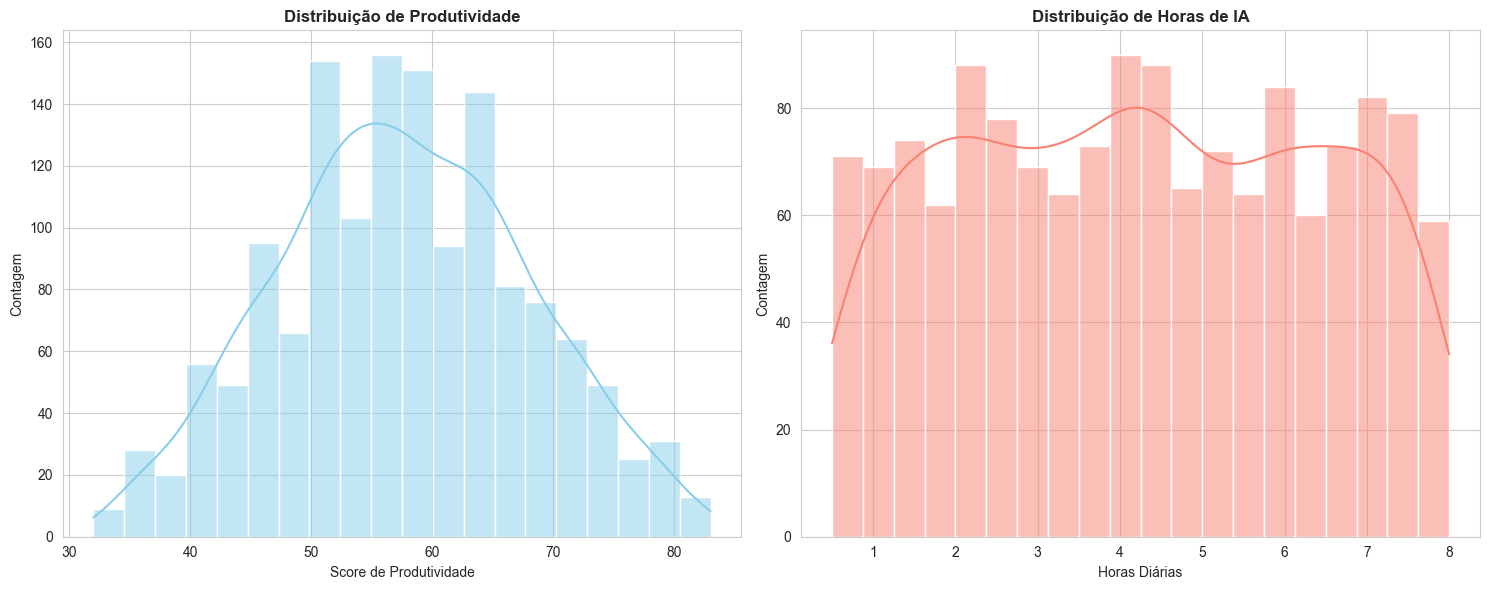

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(data=df, x='productivity_score', kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição de Produtividade', fontweight='bold')
axes[0].set_xlabel('Score de Produtividade')
axes[0].set_ylabel('Contagem')

sns.histplot(data=df, x='hours_with_ai_assistance_daily', kde=True, ax=axes[1], color='salmon', bins=20)
axes[1].set_title('Distribuição de Horas de IA', fontweight='bold')
axes[1].set_xlabel('Horas Diárias')
axes[1].set_ylabel('Contagem')

plt.tight_layout()
plt.show()

## 9. 👔 Distribuição de Cargos no Dataset

Visualizamos a frequência de cada cargo de tecnologia presente no dataset. Isso nos permite entender o perfil da amostra e identificar possíveis desequilíbrios entre grupos profissionais.


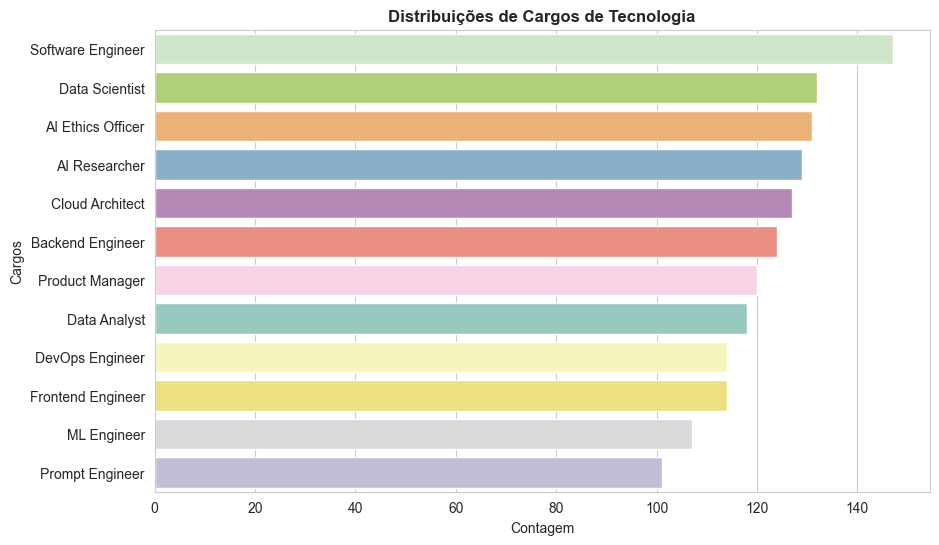

In [49]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y="job_role", order=df['job_role'].value_counts().index, hue="job_role", palette="Set3", legend=False)
plt.title("Distribuições de Cargos de Tecnologia", fontweight='bold')
plt.xlabel("Contagem")
plt.ylabel("Cargos")
plt.show()

## 10. 🚀 Maturidade na IA vs. Produtividade

Investigamos como o **estágio de adoção de IA** (`ai_adoption_stage`) impacta a produtividade dos profissionais. Os quatro estágios analisados são:

| Estágio | Descrição |
|---|---|
| `Experimenting` | Uso inicial e exploratório da IA |
| `Integrating` | Incorporação da IA em processos existentes |
| `Optimizing` | Otimização contínua dos fluxos com IA |
| `AI-First` | IA como pilar central das operações |

O boxplot revela como a consistência e o nível de produtividade evoluem com a maturidade tecnológica.


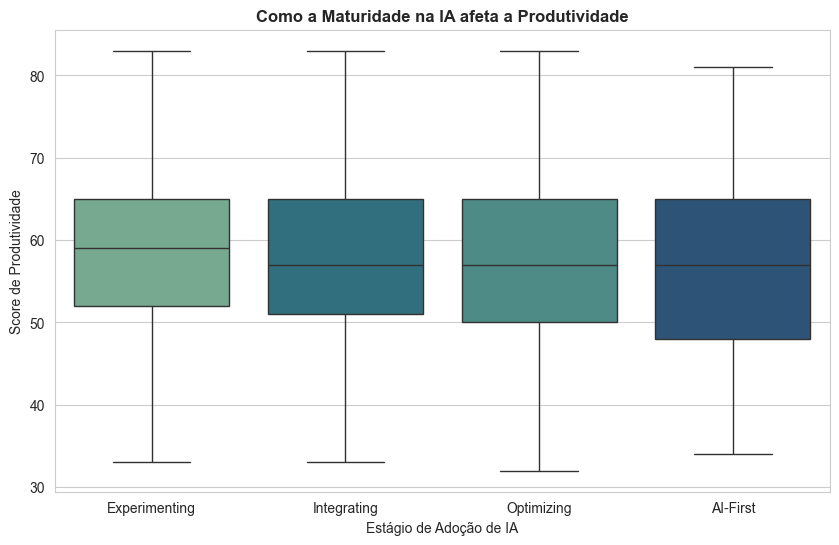

In [50]:
plt.figure(figsize=(10, 6))
order_stages = ['Experimenting', 'Integrating', 'Optimizing', 'AI-First']

sns.boxplot(data=df, x='ai_adoption_stage', y='productivity_score', order=order_stages, hue='ai_adoption_stage', palette='crest', legend=False)
plt.title('Como a Maturidade na IA afeta a Produtividade', fontweight='bold')
plt.xlabel('Estágio de Adoção de IA')
plt.ylabel('Score de Produtividade')
plt.show()

## 11. ⚡ Produtividade × Horas de IA (com Burnout como Dimensão)

Exploramos a relação entre horas diárias com IA e produtividade, utilizando o `burnout_score` como variável de cor. Isso permite identificar se profissionais mais produtivos sofrem mais ou menos burnout em função do tempo de uso de IA.


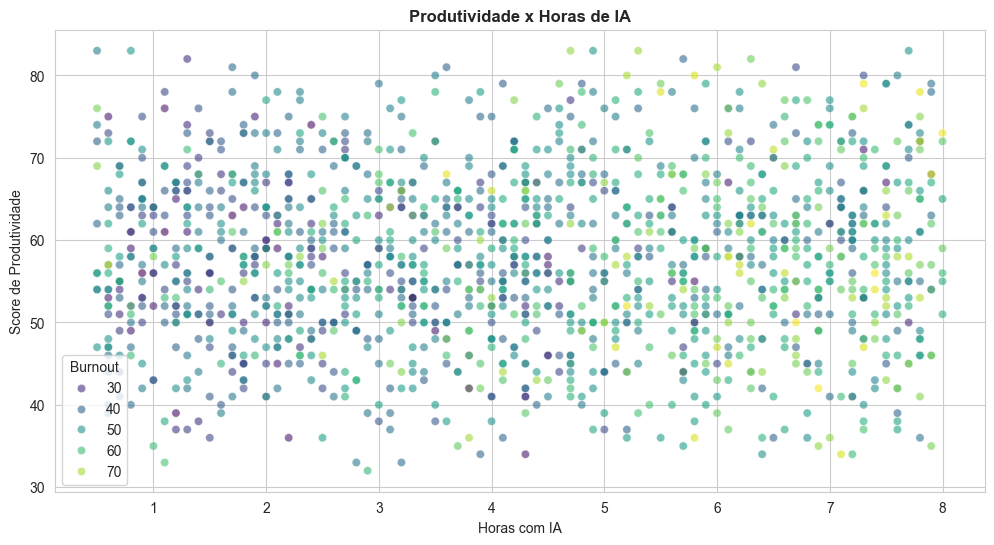

In [51]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='hours_with_ai_assistance_daily', y='productivity_score', hue='burnout_score', palette='viridis', alpha=0.6)
plt.title('Produtividade x Horas de IA', fontweight='bold')
plt.xlabel('Horas com IA')
plt.ylabel('Score de Produtividade')
plt.legend(title='Burnout')
plt.show()

## 12. 📉 Análises de Regressão

Duas relações críticas são investigadas por meio de gráficos de regressão (`regplot`):

- **Horas de IA vs. Burnout**: Avaliamos se existe tendência linear de aumento do burnout conforme o uso diário de IA cresce.
- **Substituição por IA vs. Satisfação**: Verificamos se profissionais com maior percentual de tarefas substituídas pela IA tendem a reportar menor satisfação com o trabalho.


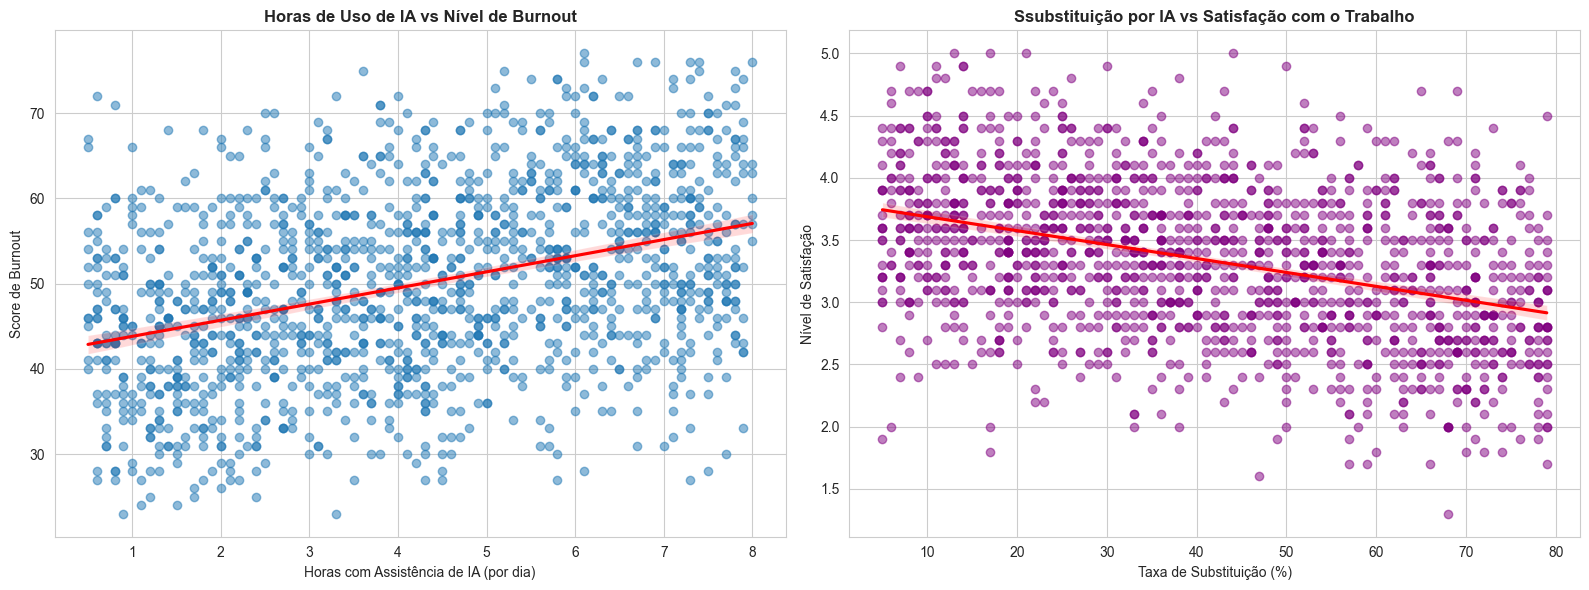

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(data=df, x='hours_with_ai_assistance_daily', y='burnout_score', line_kws={"color":"red"}, scatter_kws={'alpha':0.5}, ax=axes[0])
axes[0].set_title('Horas de Uso de IA vs Nível de Burnout', fontweight='bold')
axes[0].set_xlabel('Horas com Assistência de IA (por dia)')
axes[0].set_ylabel('Score de Burnout')

sns.regplot(data=df, x="ai_replaces_my_tasks_pct", y="job_satisfaction_1_5", color="purple",line_kws={"color":"red"}, scatter_kws={'alpha':0.5}, ax=axes[1])
axes[1].set_title("Ssubstituição por IA vs Satisfação com o Trabalho", fontweight='bold')
axes[1].set_xlabel("Taxa de Substituição (%)")
axes[1].set_ylabel("Nível de Satisfação")

plt.tight_layout()
plt.show()

## 13. 📚 Carga de Upskilling vs. Burnout (por Risco de Atrito)

Analisamos o impacto das **horas semanais de aprendizado em IA** (`weekly_ai_upskilling_hrs`) sobre o burnout, segmentando os profissionais por **risco de atrito** (`attrition_risk`).

A hipótese investigada é: profissionais que precisam se recapacitar continuamente para acompanhar a IA enfrentam maior pressão psicológica?


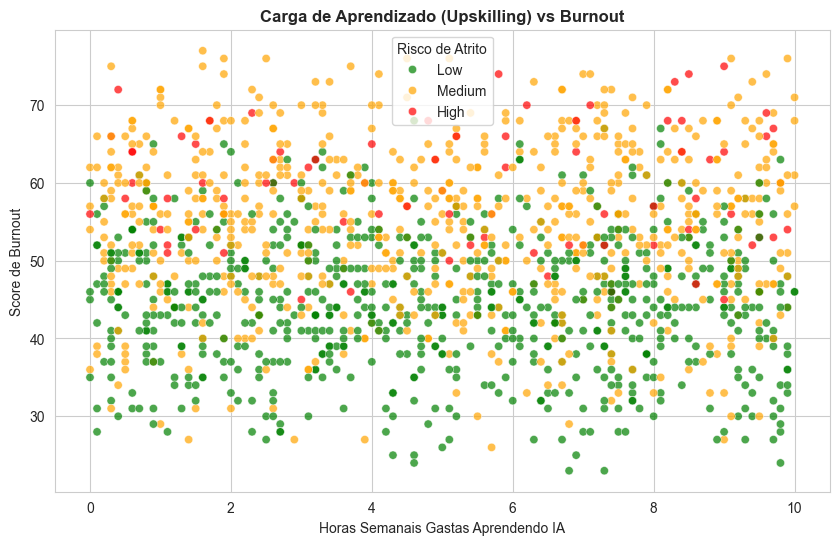

In [53]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='weekly_ai_upskilling_hrs', y='burnout_score', hue='attrition_risk', hue_order=['Low', 'Medium', 'High'], palette={'Low': 'green', 'Medium': 'orange', 'High': 'red'}, alpha=0.7)

plt.title('Carga de Aprendizado (Upskilling) vs Burnout', fontweight='bold')
plt.xlabel('Horas Semanais Gastas Aprendendo IA')
plt.ylabel('Score de Burnout')
plt.legend(title='Risco de Atrito')
plt.show()

## 14. 🏅 Distribuição de Burnout por Anos de Experiência

Examinamos como o burnout varia entre faixas de senioridade (`years_experience`). O boxplot por grupo permite identificar se profissionais em estágios específicos da carreira são mais suscetíveis ao esgotamento — considerando que os outliers já foram removidos por grupo nesta variável.


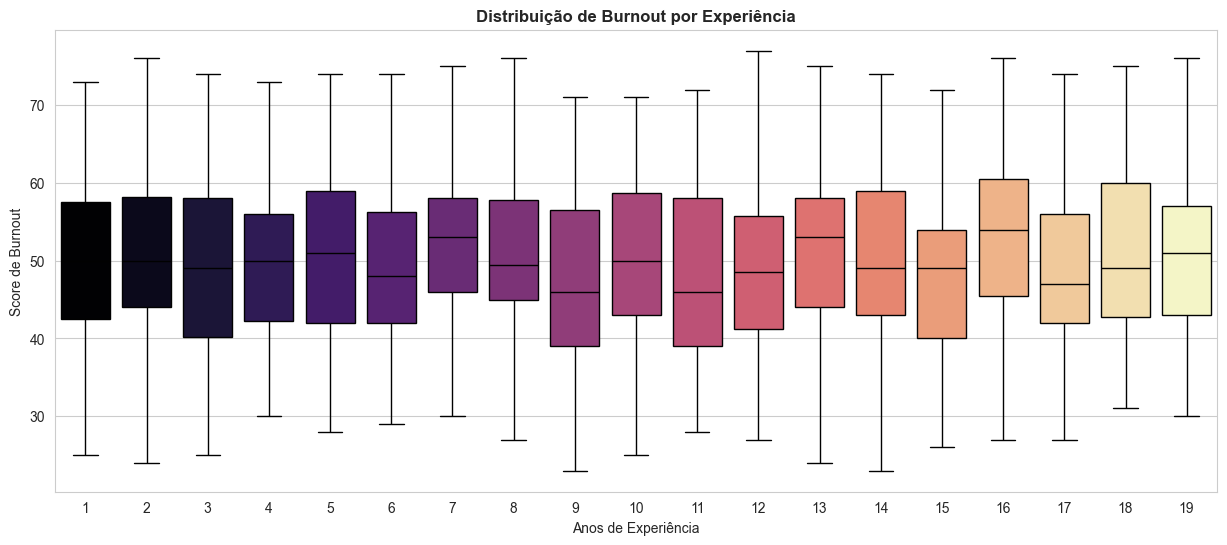

In [54]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=df, x='years_experience', y='burnout_score', hue='years_experience', palette='magma', legend=False)
plt.title('Distribuição de Burnout por Experiência', fontweight='bold')
plt.xlabel('Anos de Experiência')
plt.ylabel('Score de Burnout')
plt.show()

## 15. 😰 Risco de Atrito, Burnout e Medo de Substituição

Combinamos três dimensões psicológicas e comportamentais:
- **Risco de Atrito** (`attrition_risk`): probabilidade de o profissional deixar a empresa.
- **Score de Burnout** (`burnout_score`): nível de esgotamento reportado.
- **Medo de Substituição por IA** (`fear_of_ai_replacement`): percepção de ameaça ao emprego.

O gráfico de barras agrupadas revela como esses fatores se combinam e se intensificam mutuamente.


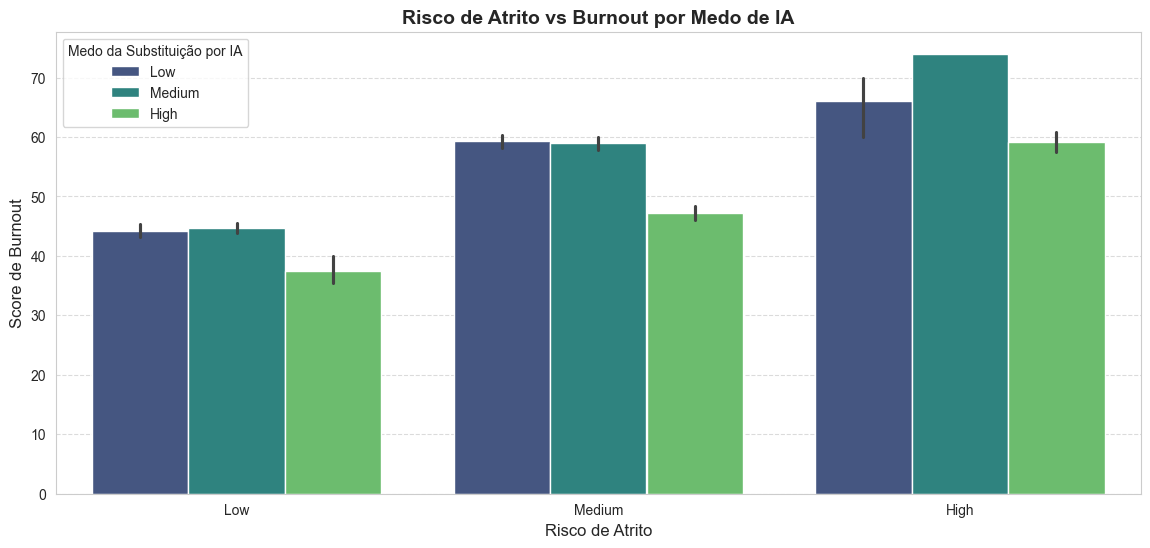

In [55]:
plt.figure(figsize=(14, 6))
ordem_risco = ['Low', 'Medium', 'High']
ordem_medo = ['Low', 'Medium', 'High']

sns.barplot(data=df, x='attrition_risk', y='burnout_score', hue='fear_of_ai_replacement', order=ordem_risco, hue_order=ordem_medo, palette="viridis")

plt.title('Risco de Atrito vs Burnout por Medo de IA', fontsize=14, fontweight='bold')
plt.xlabel('Risco de Atrito', fontsize=12)
plt.ylabel('Score de Burnout', fontsize=12)
plt.legend(title="Medo da Substituição por IA", loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 16. 🎓 Burnout por Nível de Escolaridade

Investigamos se o nível de formação acadêmica influencia o burnout. O violin plot exibe tanto a distribuição completa quanto os quartis internos, permitindo comparar o perfil de esgotamento entre:
`Self-taught` → `Bootcamp` → `Bachelor` → `Master` → `PhD`


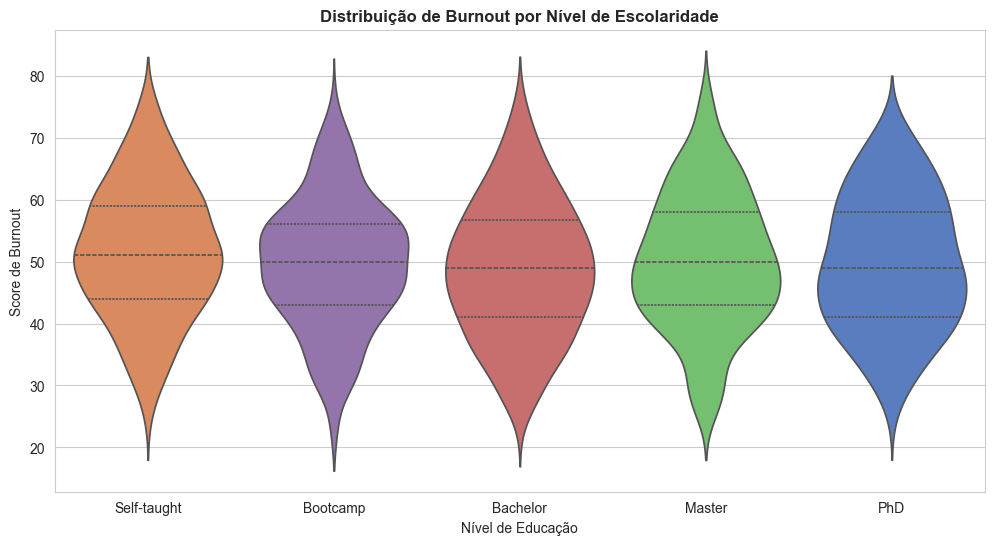

In [56]:
plt.figure(figsize=(12, 6))
education_order = ['Self-taught', 'Bootcamp', 'Bachelor', 'Master', 'PhD']

sns.violinplot(data=df, x='education_level', y='burnout_score', order=education_order, hue='education_level', palette='muted', inner='quartile', legend=False)
plt.title('Distribuição de Burnout por Nível de Escolaridade', fontweight='bold')
plt.xlabel('Nível de Educação')
plt.ylabel('Score de Burnout')
plt.show()

## 17. 🔬 Análise Multivariada: IA, Burnout, Atrito e Medo de Substituição

Utilizamos um `relplot` com facetas por **risco de atrito** para analisar simultaneamente quatro variáveis:
- Horas com IA (eixo X)
- Burnout (eixo Y)
- Risco de Atrito (colunas/facetas)
- Medo de Substituição (cor dos pontos)

Esta é a visão mais rica do notebook, evidenciando como o contexto emocional e a exposição à IA interagem no perfil de risco de cada profissional.


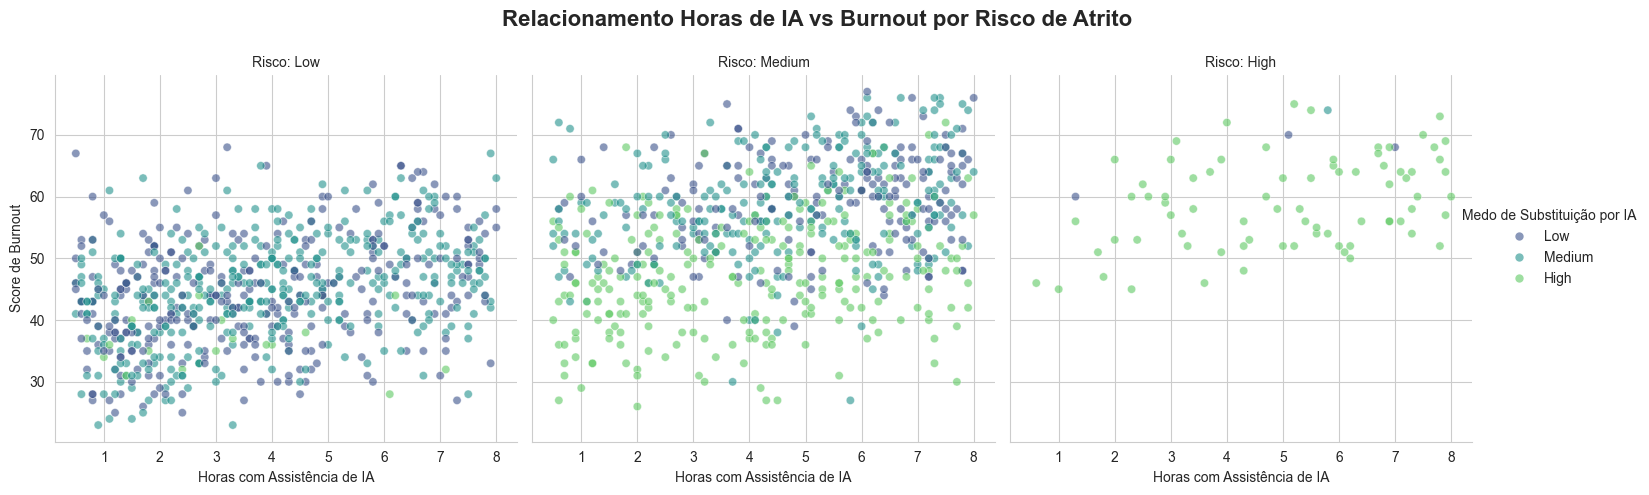

In [57]:
g = sns.relplot(data=df, x='hours_with_ai_assistance_daily', y='burnout_score', col='attrition_risk', col_order=['Low', 'Medium', 'High'], hue='fear_of_ai_replacement', kind='scatter', palette='viridis', alpha=0.6)

g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('Relacionamento Horas de IA vs Burnout por Risco de Atrito', fontweight='bold', fontsize=16)
g.set_axis_labels('Horas com Assistência de IA', 'Score de Burnout')
g.set_titles("Risco: {col_name}")
g._legend.set_title("Medo de Substituição por IA")
plt.show()

### 📊 Resumo Estatístico e Principais Insights

Após a limpeza de outliers e análise multivariada, os seguintes padrões foram identificados:

1.  **Carga de Trabalho e Burnout:**
    *   Existe uma correlação positiva moderada entre as **horas diárias com assistência de IA** e o **score de burnout**. Profissionais que utilizam IA por mais de 6 horas diárias tendem a reportar níveis de exaustão mais elevados.
    *   O **Upskilling semanal** (horas de estudo) atua como um fator de pressão: quanto mais horas gastas tentando acompanhar a evolução da IA, maior o risco de atrito percebido.

2.  **Risco de Atrito e Medo de Substituição:**
    *   O grupo de **Alto Risco de Atrito** apresenta a média de burnout mais alta (~74.0), especialmente quando o medo de substituição por IA é 'Médio' ou 'Alto'.
    *   Curiosamente, o medo 'Baixo' de substituição por IA correlaciona-se com maior satisfação no trabalho e menor burnout, independentemente do cargo.

3.  **Produtividade vs. Maturidade Tecnológica:**
    *   Empresas nos estágios de **'Optimizing'** e **'AI-First'** demonstram scores de produtividade significativamente mais altos e consistentes do que aquelas em estágio de 'Experimenting'.
    *   Cargos como **Data Scientist** e **AI Researcher** possuem as maiores taxas de substituição de tarefas por IA, mas mantêm produtividade elevada.

4.  **Educação e Perfil Profissional:**
    *   O nível de escolaridade não é um preditor direto de burnout, sugerindo que o estresse tecnológico afeta igualmente profissionais de todos os backgrounds (desde autodidatas a PhDs).
    *   A remoção de outliers revelou que o burnout é um fenômeno generalizado em profissionais com 5 a 12 anos de experiência (mid-career).

---

# 🧠 Parte II — Modelagem Preditiva com Machine Learning

Após a análise exploratória, avançamos para a etapa de **modelagem preditiva**, com dois objetivos:

1. **Classificação**: Prever o **risco de atrito** (`attrition_risk`) — variável categórica (Low / Medium / High).
2. **Regressão**: Prever o **score de burnout** (`burnout_score`) — variável numérica contínua.

Para cada objetivo, comparamos dois algoritmos de ensemble baseados em árvores:
- **Random Forest** — robusto, interpretável e excelente como baseline.
- **XGBoost** — geralmente mais performático e otimizado para dados tabulares.

---

## 18. ⚙️ Preparação dos Dados para Machine Learning

Antes de treinar qualquer modelo, precisamos transformar os dados em um formato adequado para algoritmos de ML:

- **Remoção do `employee_id`**: identificador único que não tem valor preditivo.
- **Codificação do target**: `LabelEncoder` transforma `attrition_risk` (Low / Medium / High) em valores numéricos (0 / 1 / 2) na coluna `attrition_risk_encoded`.
- **One-Hot Encoding** (`pd.get_dummies`): converte variáveis categóricas em colunas binárias. Usamos `drop_first=True` para evitar multicolinearidade.

Variáveis categóricas codificadas: `job_role`, `education_level`, `country`, `industry`, `company_size`, `remote_work_type`, `primary_ai_tool`, `ai_adoption_stage`, `fear_of_ai_replacement`.

O DataFrame resultante (`df_ml`) contém apenas valores numéricos, pronto para os algoritmos.


In [58]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.drop(columns=['employee_id'])

le = LabelEncoder()
df_ml['attrition_risk_encoded'] = le.fit_transform(df_ml['attrition_risk'])

cat_cols = ['job_role', 'education_level', 'country', 'industry', 'company_size',
            'remote_work_type', 'primary_ai_tool', 'ai_adoption_stage', 'fear_of_ai_replacement']

df_ml = pd.get_dummies(df_ml, columns=cat_cols, drop_first=True)

display(df_ml.head())

,years_experience,team_size,salary_usd_k,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,...,primary_ai_tool_Gemini,primary_ai_tool_GitHub Copilot,primary_ai_tool_Midjourney,primary_ai_tool_Notion AI,primary_ai_tool_Perplexity,ai_adoption_stage_Experimenting,ai_adoption_stage_Integrating,ai_adoption_stage_Optimizing,fear_of_ai_replacement_Low,fear_of_ai_replacement_Medium
0,7,8,184,1,0.6,37,4.9,59,58,3.0,...,False,True,False,False,False,True,False,False,True,False
1,3,42,51,3,0.6,78,6.6,64,47,3.6,...,False,False,False,False,False,True,False,False,False,True
2,3,37,185,4,4.0,23,5.8,50,37,4.6,...,False,False,True,False,False,False,False,True,False,False
3,18,8,131,5,4.2,75,1.4,77,67,3.0,...,False,False,False,False,True,False,True,False,True,False
4,5,21,99,7,0.7,61,1.6,58,54,3.6,...,False,False,False,True,False,True,False,False,False,True


## 19. 🌳 Classificação — Random Forest para Risco de Atrito

Treinamos um **Random Forest Classifier** para prever o risco de atrito a partir das variáveis comportamentais e demográficas dos profissionais.

**Detalhes do experimento:**
- **Features (X):** todas as colunas, exceto o target e sua versão original.
- **Target (y):** `attrition_risk_encoded` (Low=0, Medium=1, High=2).
- **Divisão:** 80% treino / 20% teste (`random_state=42` para reprodutibilidade).
- **`class_weight='balanced'`**: compensação automática para o desbalanceamento entre as classes de risco.


In [59]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df_ml.drop(columns=["attrition_risk_encoded", "attrition_risk"])
y = df_ml["attrition_risk_encoded"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = RandomForestClassifier(random_state=42, class_weight='balanced')

modelo.fit(X_train, y_train)

p_rfc = modelo.predict(X_test)

### 19.1 — Avaliação do Random Forest Classifier

Avaliamos o desempenho do modelo através de duas métricas complementares:

- **Matriz de Confusão**: visualiza acertos e erros por classe, mostrando onde o modelo confunde categorias.
- **Classification Report**: apresenta precisão, recall e F1-score por classe, além do *support* (quantidade de amostras de cada classe no teste).


In [60]:
from sklearn.metrics import classification_report, confusion_matrix

print("--- Matriz de Confusão ---")
print(confusion_matrix(y_test, p_rfc))

print("\n--- Relatório de Classificação ---")
print(classification_report(y_test, p_rfc, zero_division=0))

--- Matriz de Confusão ---
[[  0   0  13]
 [  0 122  13]
 [  0  22 123]]

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.85      0.90      0.87       135
           2       0.83      0.85      0.84       145

    accuracy                           0.84       293
   macro avg       0.56      0.58      0.57       293
weighted avg       0.80      0.84      0.82       293



## 20. ⚡ Classificação — XGBoost para Risco de Atrito

Para fins comparativos, treinamos um **XGBoost Classifier** no mesmo problema. O XGBoost frequentemente supera o Random Forest em dados tabulares devido ao seu mecanismo de *gradient boosting*.

**Particularidades da implementação:**
- A função `colunas_limpas` remove caracteres especiais (`[`, `]`, `<`) dos nomes das colunas — o XGBoost não aceita esses símbolos.
- Em vez de `class_weight`, usamos `compute_sample_weight` para gerar pesos por amostra e compensar o desbalanceamento de classes.


In [61]:
import re
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

def colunas_limpas(df):
    df.columns = [re.sub(r'[\[\]<]', '', col) for col in df.columns]
    return df

X = colunas_limpas(X)
X_train = colunas_limpas(X_train)
X_test = colunas_limpas(X_test)

pesos = compute_sample_weight(class_weight='balanced', y=y_train)

modelo_xgb = XGBClassifier(random_state=42)
modelo_xgb.fit(X_train, y_train, sample_weight=pesos)

p_xgb = modelo_xgb.predict(X_test)

### 20.1 — Avaliação do XGBoost Classifier

Aplicamos as mesmas métricas usadas no Random Forest, permitindo uma comparação direta entre os dois modelos de classificação.


In [62]:
from sklearn.metrics import classification_report, confusion_matrix

print("--- Matriz de Confusão ---")
print(confusion_matrix(y_test, p_xgb))

print("\n--- Relatório de Classificação ---")
print(classification_report(y_test, p_xgb))

--- Matriz de Confusão ---
[[  7   0   6]
 [  0 120  15]
 [  7  22 116]]

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       0.50      0.54      0.52        13
           1       0.85      0.89      0.87       135
           2       0.85      0.80      0.82       145

    accuracy                           0.83       293
   macro avg       0.73      0.74      0.74       293
weighted avg       0.83      0.83      0.83       293



---

## 21. 📈 Regressão — Random Forest para Previsão de Burnout

Mudamos o tipo de problema: agora o objetivo é **prever o score numérico de burnout** (`burnout_score`), o que caracteriza uma tarefa de **regressão**.

**Configuração do experimento:**
- **Features (X):** todas as colunas, exceto `burnout_score`, `attrition_risk` e `attrition_risk_encoded` (para evitar vazamento de informação do target).
- **Target (y):** `burnout_score`.
- **Modelo:** `RandomForestRegressor` com 100 estimadores.
- **Métricas avaliadas:**
  - **MAE (Mean Absolute Error)**: erro médio absoluto entre as predições e os valores reais.
  - **R² (Coeficiente de Determinação)**: proporção da variância explicada pelo modelo (0 = aleatório, 1 = perfeito).


In [63]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Preparação dos dados para Regressão
X_reg = df_ml.drop(columns=['burnout_score', 'attrition_risk', 'attrition_risk_encoded'])
y_reg = df_ml['burnout_score']

# 2. Divisão Treino/Teste
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 3. Treinamento do Modelo
modelo_rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf_reg.fit(X_train_reg, y_train_reg)

# 4. Predição
rf_burnout_preds = modelo_rf_reg.predict(X_test_reg)

# 5. Avaliação
mae_rf = mean_absolute_error(y_test_reg, rf_burnout_preds)
r2_rf = r2_score(y_test_reg, rf_burnout_preds)

print(f"--- Avaliação do Random Forest Regressor ---")
print(f"Erro Médio Absoluto (MAE): {mae_rf:.2f}")
print(f"Coeficiente de Determinação (R²): {r2_rf:.2f}")

--- Avaliação do Random Forest Regressor ---
Erro Médio Absoluto (MAE): 5.78
Coeficiente de Determinação (R²): 0.53


## 22. 🚀 Regressão — XGBoost para Previsão de Burnout

Finalmente, testamos o **XGBoost Regressor** no mesmo problema de regressão. Esperamos um desempenho superior ou comparável ao Random Forest, mantendo as mesmas métricas (MAE e R²) para comparação justa.

A função `clean_xgb_columns` mais uma vez sanitiza os nomes das colunas para compatibilidade com o XGBoost.


In [64]:
import re
from xgboost import XGBRegressor

def clean_xgb_columns(df):
    df.columns = [re.sub(r'[\[\]<]', '', col) for col in df.columns]
    return df

X_train_reg = clean_xgb_columns(X_train_reg.copy())
X_test_reg = clean_xgb_columns(X_test_reg.copy())

modelo_reg2 = XGBRegressor(random_state=42)
modelo_reg2.fit(X_train_reg, y_train_reg)

xgbr_burnout = modelo_reg2.predict(X_test_reg)

maexgb = mean_absolute_error(y_test_reg, xgbr_burnout)
r2xgb = r2_score(y_test_reg, xgbr_burnout)

print(f"--- Avaliação do Modelo XGBoost (Burnout) ---")
print(f"Erro Médio Absoluto (MAE): {maexgb:.2f}")
print(f"Coeficiente de Determinação (R²): {r2xgb:.2f}")

--- Avaliação do Modelo XGBoost (Burnout) ---
Erro Médio Absoluto (MAE): 6.43
Coeficiente de Determinação (R²): 0.44


---

## 🏁 Conclusão Final

Este notebook combinou **análise exploratória** com **modelagem preditiva** para investigar a influência da IA no ambiente de trabalho:

- **EDA**: Identificamos padrões claros entre uso intensivo de IA, burnout, satisfação e risco de atrito.
- **Classificação**: Construímos modelos para antecipar o risco de desligamento, comparando Random Forest e XGBoost.
- **Regressão**: Estimamos o nível de burnout a partir de variáveis comportamentais e demográficas, novamente comparando duas abordagens.

Os resultados podem servir de base para que empresas de tecnologia desenhem **estratégias de retenção e bem-estar** mais direcionadas, identificando proativamente perfis em risco e atuando antes que o esgotamento ou o desligamento se concretizem.
